In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 829.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.6 MB/s eta 0:00:00


# **Libraries**

In [ ]:
from ultralytics import YOLO
model = YOLO('yolo26m-seg.pt')

### **YOLO CONFIG**

# **Live time PC window Recorder**

In [ ]:
video = '/content/Record_a_video_of_an_accident.mp4'
yolo_conf = 0.70
yolo_iou = 0.5
class_ids = [2, 3, 5, 7]

In [ ]:
results = model.track(
    source = video,
    conf = yolo_conf,
    iou = yolo_iou,
    show = False,
    save = True,
    classes = class_ids,
    persist = True,
    imgsz=960,
    tracker = "bytetrack.yaml" )

print(f"Processing complete. The output video is saved in the 'runs/detect/track' folder.")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 332ms
Prepared 1 package in 59ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/240) /content/Record_a_video_of_an_accident.mp4: 544x960 (no detections), 67.1ms
v

In [ ]:
frame_data = {}

for frame_idx, result in enumerate(results):
    if result.boxes is None:
        continue

    ids = result.boxes.id
    if ids is None:
        continue

    ids = ids.cpu().numpy().astype(int)
    boxes = result.boxes.xyxy.cpu().numpy()

    for track_id, box in zip(ids, boxes):
        x1, y1, x2, y2 = box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        frame_data.setdefault(track_id, {})
        frame_data[track_id][frame_idx] = (cx, cy)

In [ ]:
frame_data

{np.int64(2): {5: (np.float32(548.46094), np.float32(39.478447)),
  8: (np.float32(548.2489), np.float32(43.15644)),
  9: (np.float32(548.0831), np.float32(44.54637)),
  10: (np.float32(548.1792), np.float32(45.78444)),
  11: (np.float32(548.3275), np.float32(46.93496)),
  12: (np.float32(548.2873), np.float32(48.016068)),
  13: (np.float32(548.3868), np.float32(49.40474)),
  14: (np.float32(547.9668), np.float32(50.952927)),
  15: (np.float32(547.2805), np.float32(52.398888)),
  16: (np.float32(546.6821), np.float32(53.76693)),
  17: (np.float32(546.16736), np.float32(55.176758)),
  18: (np.float32(547.1129), np.float32(56.47439)),
  19: (np.float32(546.9859), np.float32(57.761116)),
  20: (np.float32(547.1721), np.float32(59.329514)),
  22: (np.float32(546.9834), np.float32(62.41201)),
  23: (np.float32(546.8182), np.float32(64.12989)),
  24: (np.float32(546.4945), np.float32(65.87594)),
  25: (np.float32(545.5604), np.float32(67.37244)),
  26: (np.float32(544.14514), np.float32(68.9

In [ ]:
#####################################################################################

In [ ]:
import math

pixel_speed = {}

for track_id, frames in frame_data.items():
    pixel_speed[track_id] = {}
    frame_ids = sorted(frames.keys())

    for i in range(1, len(frame_ids)):
        prev_frame = frame_ids[i - 1]
        curr_frame = frame_ids[i]

        frame_diff = curr_frame - prev_frame

        x1, y1 = frames[prev_frame]
        x2, y2 = frames[curr_frame]

        distance = math.hypot(x2 - x1, y2 - y1)

        speed = distance / frame_diff

        pixel_speed[track_id][curr_frame] = float(speed)

In [ ]:
pixel_speed

{np.int64(2): {8: 1.2280335466937322,
  9: 1.3997812706285175,
  10: 1.2417893405150546,
  11: 1.1600407252537992,
  12: 1.0818560588692452,
  13: 1.3922310513021892,
  14: 1.6041413354279899,
  15: 1.6005569288857022,
  16: 1.4931871600762814,
  17: 1.5008678122515382,
  18: 1.6055907891529515,
  19: 1.2929815540407241,
  20: 1.579413824153607,
  22: 1.544134147208692,
  23: 1.7258073226096595,
  24: 1.7757943091670696,
  25: 1.7640906518891832,
  26: 2.087952074086936,
  27: 1.416199043681452,
  28: 1.6195693032578424,
  29: 1.8385173279581146,
  30: 1.7533379685119908,
  31: 1.565635789025155,
  32: 1.7769451884606946,
  33: 1.7394034294870713,
  34: 1.9417530043881377,
  35: 1.898168643164941,
  36: 1.7856964469558416,
  37: 1.9444504701396557,
  38: 1.7458516999789495,
  39: 1.9855505864328247,
  40: 2.5427554206176337,
  41: 2.4976662979064255,
  42: 2.1652219086150213,
  43: 1.9161149309950383,
  44: 2.291020388539314,
  45: 1.9618153203224409,
  46: 2.1514263123442072,
  47: 1.

In [ ]:
from scipy.signal import medfilt

filtered_speed = {}

for track_id, speeds in pixel_speed.items():

    frames = list(speeds.keys())
    values = list(speeds.values())

    filtered = medfilt(values, kernel_size=25)

    filtered_speed[track_id] = dict(zip(frames, filtered))

/tmp/ipykernel_769/3680529619.py:10: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  filtered = medfilt(values, kernel_size=25)


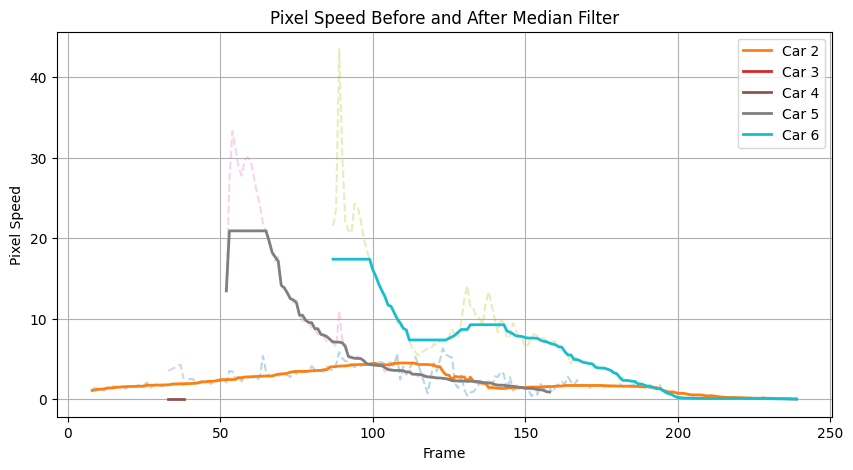

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for track_id in pixel_speed:

    frames = list(pixel_speed[track_id].keys())

    plt.plot(
        frames,
        list(pixel_speed[track_id].values()),
        alpha=0.3,
        linestyle="--"
    )

    plt.plot(
        frames,
        list(filtered_speed[track_id].values()),
        linewidth=2,
        label=f"Car {track_id}"
    )

plt.grid(True)
plt.legend()
plt.xlabel("Frame")
plt.ylabel("Pixel Speed")
plt.title("Pixel Speed Before and After Median Filter")

plt.show()

In [ ]:
#MIN_TRACK_LENGTH = 30

#filtered_speed = {
  #  track_id: speeds
 #   for track_id, speeds in filtered_speed.items()
  #  if len(speeds) >= MIN_TRACK_LENGTH
#}

In [ ]:
def dynamic_speed_filter(pixel_speed,
                         drop_ratio=0.03,
                         stop_ratio=0.05,
                         min_peak_speed=5):

    suspected_tracks = []

    for track_id, speeds in pixel_speed.items():

        if len(speeds) < 5:
            continue

        values = list(speeds.values())

        peak_speed = max(values)

        if peak_speed < min_peak_speed:
            continue

        final_speed = values[-1]

        drop = final_speed / peak_speed

        if drop <= drop_ratio and final_speed <= peak_speed * stop_ratio:
            suspected_tracks.append(track_id)

    return suspected_tracks

In [ ]:
suspected_tracks = dynamic_speed_filter(pixel_speed)

print(suspected_tracks)

[np.int64(2), np.int64(6)]


In [ ]:
import os
import cv2
import numpy as np


def extract_crash_frames(
    video_path,
    pixel_speed,
    frame_data,
    suspected_tracks,
    output_dir="/content/crashes",
    stop_threshold=1.0,
):

    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    for track_id in suspected_tracks:

        speeds = pixel_speed.get(track_id, {})

        if not speeds:
            continue

        stop_frame = None

        for frame_id, speed in sorted(speeds.items()):
            if speed <= stop_threshold:
                stop_frame = frame_id
                break

        if stop_frame is None:
            continue

        last_frame = max(frame_data[track_id].keys())

        if last_frame <= stop_frame:
            selected_frames = [stop_frame]
        else:
            selected_frames = np.linspace(
                stop_frame,
                last_frame,
                5,
                dtype=int
            )

        selected_frames = sorted(set(selected_frames))

        for frame_id in selected_frames:

            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

            ok, frame = cap.read()

            if not ok:
                continue

            filename = os.path.join(
                output_dir,
                f"track{track_id}_frame{frame_id}.png"
            )

            cv2.imwrite(filename, frame)

    cap.release()

In [ ]:
extract_crash_frames(
    video_path=video,
    pixel_speed=pixel_speed,
    frame_data=frame_data,
    suspected_tracks=suspected_tracks
)

In [ ]:
#############################################################################

In [ ]:
import torch
import numpy as np
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import cv2
import glob
import os


In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/clip-vit-large-patch14"

model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

SEVERE_PROMPTS = [
    "a photo of a severe car accident",
    "dashcam footage of a catastrophic traffic accident",
    "a photo of a deadly road accident",
    "a photo of a high speed collision",
    "a photo of a violent vehicle crash",
    "a vehicle completely crushed after a collision",
    "a photo of a totally wrecked vehicle",
    "a photo of a severe highway accident",
    "a serious multi-vehicle collision",
    "a car destroyed in a crash",
    "a photo of a rolled over vehicle",
    "an accident scene requiring emergency response"
]

NORMAL_PROMPTS = [
    "a photo of a normal driving car",
    "dashcam footage of a vehicle driving safely",
    "a photo of a parked vehicle",
    "normal highway traffic",
    "cars moving safely on the road",
    "a photo of a clean undamaged car",
    "vehicles waiting at a traffic light",
    "a photo of a normal highway scene"
]

PROMPTS = SEVERE_PROMPTS + NORMAL_PROMPTS

def clip_verify(frames, threshold=0.85):
    frame_results = []

    for i, frame in enumerate(frames):
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)

        inputs = processor(
            text=PROMPTS,
            images=image,
            return_tensors="pt",
            padding=True
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1)[0]

        severe_probs = probs[:len(SEVERE_PROMPTS)]
        total_severe_score = torch.sum(severe_probs).item()
        best_index = torch.argmax(severe_probs).item()

        frame_results.append({
            "frame_id": i,
            "prompt": SEVERE_PROMPTS[best_index],
            "score": total_severe_score
        })

    frame_results = sorted(frame_results, key=lambda x: x["score"], reverse=True)

    best_frame = frame_results[0]
    confidence = best_frame["score"]

    return {
        "is_severe_accident": confidence > threshold,
        "confidence": float(confidence),
        "best_frame": best_frame,
        "all_frames": frame_results
    }

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:

frames = []

for img in sorted(glob.glob("/content/crashes/*.png")):
    frames.append(cv2.imread(img))

result = clip_verify(frames)

print(result)

{'is_severe_accident': True, 'confidence': 0.9693870544433594, 'best_frame': {'frame_id': 5, 'prompt': 'a photo of a high speed collision', 'score': 0.9693870544433594}, 'all_frames': [{'frame_id': 5, 'prompt': 'a photo of a high speed collision', 'score': 0.9693870544433594}, {'frame_id': 3, 'prompt': 'a photo of a high speed collision', 'score': 0.9606142640113831}, {'frame_id': 6, 'prompt': 'a photo of a high speed collision', 'score': 0.9599558115005493}, {'frame_id': 7, 'prompt': 'a photo of a high speed collision', 'score': 0.9597115516662598}, {'frame_id': 4, 'prompt': 'a photo of a high speed collision', 'score': 0.9466170072555542}, {'frame_id': 9, 'prompt': 'a photo of a high speed collision', 'score': 0.9466170072555542}, {'frame_id': 8, 'prompt': 'a photo of a high speed collision', 'score': 0.9464030265808105}, {'frame_id': 2, 'prompt': 'a photo of a high speed collision', 'score': 0.9325894713401794}, {'frame_id': 1, 'prompt': 'a photo of a high speed collision', 'score':